# Symbolic Differentiation

Symbolic differentiation mimics programmatically what you do by hand when calculating derivatives.
It works by building up a representation of the mathematical expression that you want to differentiate.  This is called an *expression tree*.  
Expression trees are made out of nodes that can be either operators or operands.
Operators are things like +, -, *, /, or functions like sin, cos, exp, log, etc.
Operands are things like numbers, variables, or other expressions.

For example, the expression:

$$
f(x) = 1 + x^2
$$

would be represented by the following expression tree.
The diagrams use shaded rounded rectangles for operators and unfilled ellipses for operands. The label `sqr` denotes squaring, and `pow` denotes exponentiation.



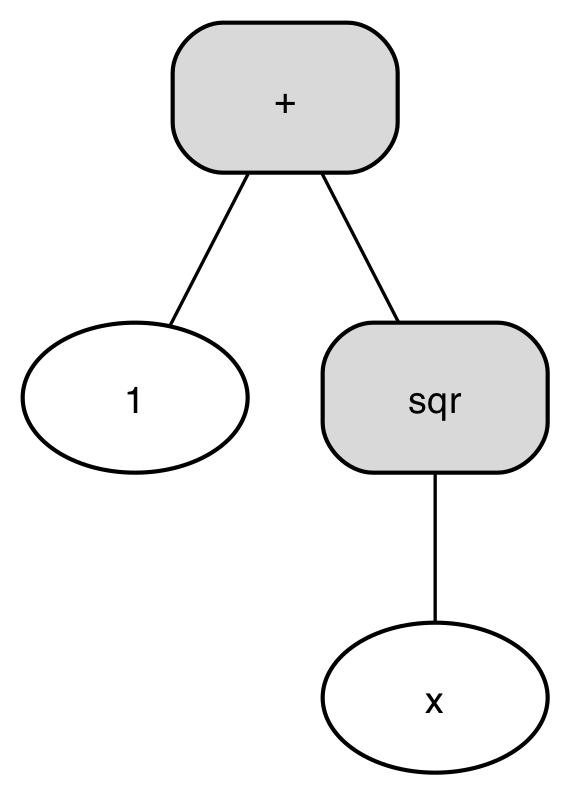

In [1]:
import base64

import graphviz
from IPython.display import display

g = graphviz.Digraph(
    graph_attr={"bgcolor": "transparent", "margin": "0.02", "ordering": "out"},
    node_attr={
        "fontname": "DejaVu Sans", "fontsize": "9",
        "color": "black", "penwidth": "1.0",
    },
    edge_attr={"arrowhead": "none", "color": "black", "penwidth": "0.8"},
)

operator_node = {
    "shape": "box", "style": "rounded,filled",
    "fillcolor": "gray85", "color": "black",
}
operand_node = {
    "shape": "ellipse", "style": "filled",
    "fillcolor": "white", "color": "black",
}

def display_graph(graph):
    """Display vector web output and print-compatible PDF/PNG fallbacks."""
    svg = graph.pipe(format="svg").decode("utf-8")
    pdf = graph.pipe(format="pdf")
    graph.graph_attr["dpi"] = "300"
    try:
        png = graph.pipe(format="png")
    finally:
        graph.graph_attr.pop("dpi", None)
    display(
        {
            "image/svg+xml": svg,
            "application/pdf": base64.b64encode(pdf).decode("ascii"),
            "image/png": base64.b64encode(png).decode("ascii"),
        },
        raw=True,
    )

g.node('+', **operator_node)
g.node('sqr', **operator_node)
g.node('1', **operand_node)
g.node('x', **operand_node)
g.edge('+', '1')
g.edge('+', 'sqr')
g.edge('sqr', 'x')
display_graph(g)

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


Matplotlib is building the font cache; this may take a moment.


Here is an expression tree for:

$$
f(x,y) = \left(\frac{\sin x}{x}\right)^2 + y^3.
$$

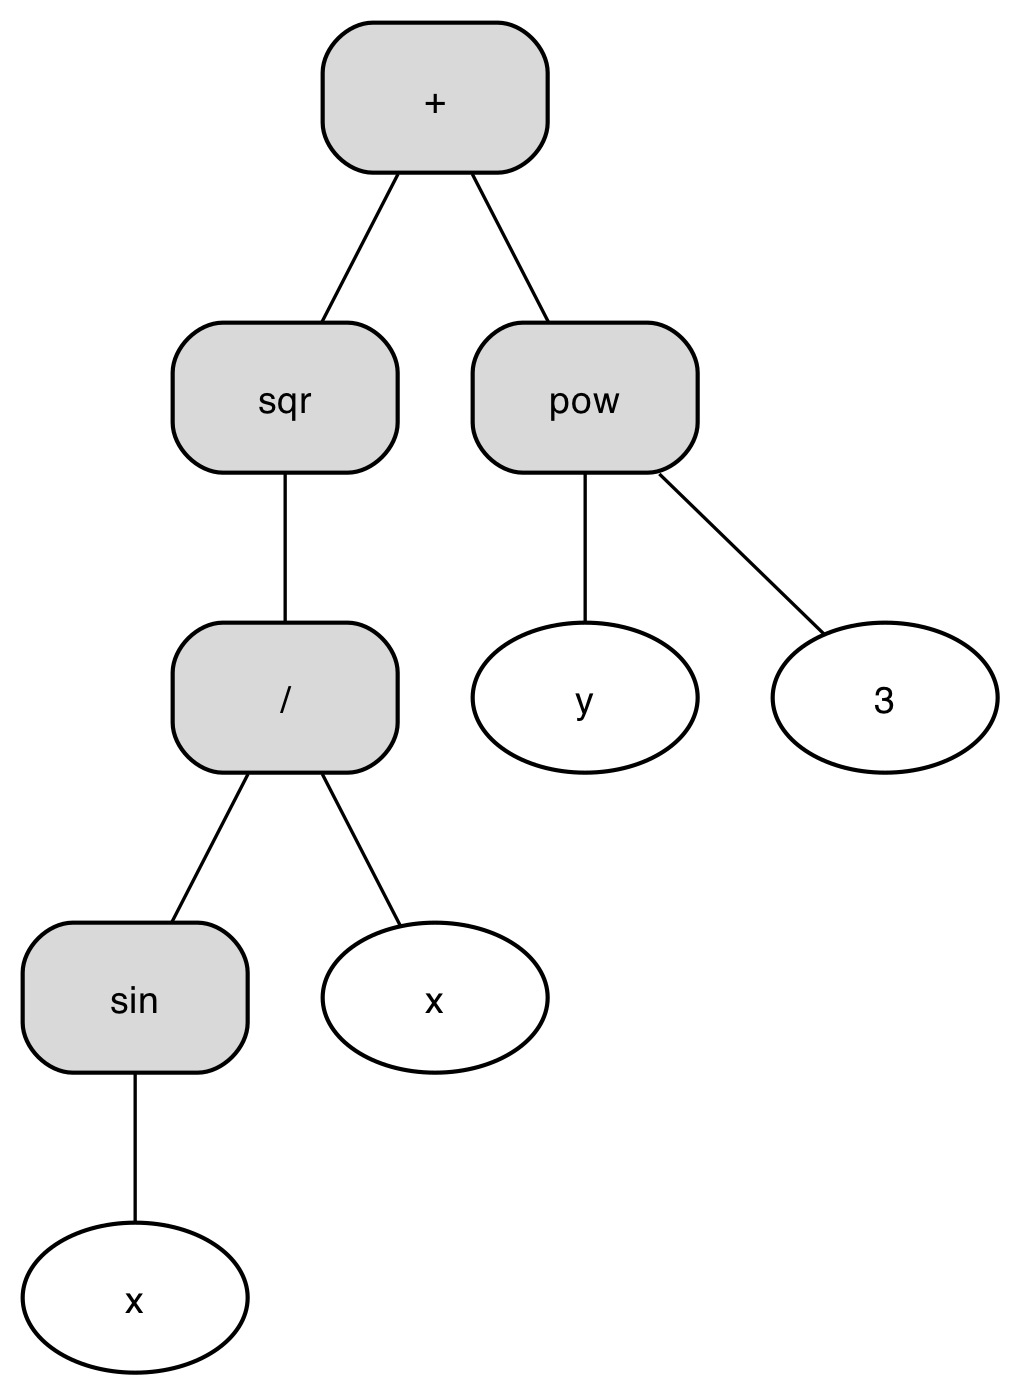

In [3]:
g = graphviz.Digraph(
    graph_attr={"bgcolor": "transparent", "margin": "0.02", "ordering": "out"},
    node_attr={
        "fontname": "DejaVu Sans", "fontsize": "9",
        "color": "black", "penwidth": "1.0",
    },
    edge_attr={"arrowhead": "none", "color": "black", "penwidth": "0.8"},
)

g.node('+', **operator_node)
g.node('sqr', **operator_node)
g.node('sin', **operator_node)
g.node('pow', **operator_node)
g.node('/', **operator_node)
g.node('3', **operand_node)
# make two different nodes for x
g.node('x1', label='x', **operand_node)
g.node('x2', label='x', **operand_node)
g.node('y', **operand_node)

g.edge('sin', 'x1')
g.edge('/', 'sin')
g.edge('/', 'x2')
g.edge('sqr', '/')
g.edge('+', 'sqr')
g.edge('+', 'pow')
g.edge('pow', 'y')
g.edge('pow', '3')

display_graph(g)

You get the idea.

One of the first thing that we would like to do is evaluate the expression.
Here is pseudocode for how to evaluate an expression tree:

```python
    def evaluate(node):
        if node is an operator:
            evaluate the operands
            apply the operator to the operands
            return the result
        else:
            return the value of the operand
```

Similarly, we can write generic code to differentiate an expression tree with respect to a variable.
To write such code, we need to know the derivative of each operator and the chain rule.
For example, the derivative of the addition operator is:

$$
\partial_x (f + g) = \partial_x f + \partial_x g.
$$

Here we are using the notation $\partial_x f$ to mean the gradient of $f$ with respect to the variable $x$, i.e., $\partial_x f = \frac{\partial f}{\partial x}$.

Similarly, for the multiplication operator:

$$
\partial_x (f g) = f \partial_x g + g \partial_x f.
$$

And so on for all operators.

Equipped with these basic operations, we can write a generic function to differentiate an expression tree with respect to a variable:

```python
    def differentiate(node, variable):
        if node is an operator:
            differentiate the operands
            apply the derivative rule for the operator to the operands
            return the result
        else:
            if node is the variable:
                return 1
            else:
                return 0
```

For a deeper treatment, see *Structure and Interpretation of Computer Programs* {cite:p}`abelson1996sicp`.

The Python package `sympy` is a library for symbolic mathematics.
Let's use it to build these trees.

In [4]:
import sympy
from sympy.abc import x, y

f = (sympy.sin(x) / x) ** 2 + y ** 3

f

y**3 + sin(x)**2/x**2

Here is the expression tree as it is internally represented by `sympy`.

In [5]:
sympy.srepr(f)

"Add(Pow(Symbol('y'), Integer(3)), Mul(Pow(Symbol('x'), Integer(-2)), Pow(sin(Symbol('x')), Integer(2))))"

You can evaluate the expression tree:

In [6]:
f.evalf(subs={x: 1, y: 2})

8.70807341827357

Or you can make a python function that evaluates the expression tree at any point:

In [7]:
f_func = sympy.lambdify([x, y], f)

f_func(1, 2)

np.float64(8.708073418273571)

And of course, you can differentiate the expression tree:

In [8]:
# Differentiate with respect to x
pxf = f.diff(x)
pxf

2*sin(x)*cos(x)/x**2 - 2*sin(x)**2/x**3

And you can evaluate that anywhere you want:

In [9]:
pxf_func = sympy.lambdify([x, y], pxf)

pxf_func(1, 2)

np.float64(-0.5068494097214605)

There are a few problems with this approach.
First, it is hard to differentiate through loops and conditionals symbolically.
This restricts quite a bit the kind of functions that you can differentiate.
Second, the expression trees can get quite large and complicated very quickly.
This is called the *expression swell* problem.

Here is an example of expression swell.
We use the softplus function, a smooth approximation to $\max(0,z)$, nested a few times:

In [10]:
w, b = sympy.symbols('w b')
# Softplus
f = sympy.log(1 + sympy.exp(w * x + b))
f

log(exp(b + w*x) + 1)

Here is the gradient of this function with respect to $w$:

In [11]:
f.diff(w)

x*exp(b + w*x)/(exp(b + w*x) + 1)

Now let's nest the softplus function a few more times:

In [12]:
f2 = sympy.log(1 + sympy.exp(w * f + b))
f2

log(exp(b + w*log(exp(b + w*x) + 1)) + 1)

Here is the derivative now:

In [13]:
f2.diff(w)

(w*x*exp(b + w*x)/(exp(b + w*x) + 1) + log(exp(b + w*x) + 1))*exp(b + w*log(exp(b + w*x) + 1))/(exp(b + w*log(exp(b + w*x) + 1)) + 1)

Okay, one more time to make the point:

In [14]:
f3 = sympy.log(1 + sympy.exp(w * f2 + b))
f3

log(exp(b + w*log(exp(b + w*log(exp(b + w*x) + 1)) + 1)) + 1)

Differentiate:

In [15]:
f3.diff(w)

(w*(w*x*exp(b + w*x)/(exp(b + w*x) + 1) + log(exp(b + w*x) + 1))*exp(b + w*log(exp(b + w*x) + 1))/(exp(b + w*log(exp(b + w*x) + 1)) + 1) + log(exp(b + w*log(exp(b + w*x) + 1)) + 1))*exp(b + w*log(exp(b + w*log(exp(b + w*x) + 1)) + 1))/(exp(b + w*log(exp(b + w*log(exp(b + w*x) + 1)) + 1)) + 1)

You get it now.